<a href="https://colab.research.google.com/github/Gao-Mm/quant-work/blob/main/Diamond_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective**

This mini-project simulates a simplified diamond sales planning and inventory analysis process inspired by the responsibilities of a Sales Planning Analyst. The objective is to compare forecast demand with available stock across sales periods (“sights”) in order to identify stock shortages, surplus inventory, and fulfilment performance. The analysis demonstrates how structured data can support planning decisions, stock balancing, and sales operations reporting.

**Business Problem**

In a diamond sales environment, poor alignment between forecast demand and available stock can create two operational problems:

Unmet demand, where forecast demand exceeds stock and sales opportunities may be lost.
Surplus stock, where inventory remains above forecast demand and may indicate inefficiencies in stock allocation.

To support better planning, the business needs visibility into:

whether stock is sufficient to meet forecast demand,
where shortages occur,
where excess stock exists, and
how effectively demand is being fulfilled across sight periods.

**Dataset**

The dataset used in this exercise contains 12 simulated sight periods. For each sight period, the following variables were recorded:

sight_period – the sales cycle / planning period
forecast_demand_carats – projected demand for diamonds in carats
available_stock_carats – stock available to satisfy forecast demand
fulfilled_carats – actual demand that can be satisfied from available stock
unmet_demand_carats – demand that could not be fulfilled because stock was insufficient
surplus_stock_carats – stock remaining after forecast demand has been met
fulfilment_rate_pct – percentage of forecast demand fulfilled

The dataset was designed to create a mix of:

fully fulfilled periods,
shortage periods,
and surplus periods

so that the planning metrics could be tested.

In [7]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sight_period = ['sight1', 'sight2', 'sight3', 'sight4', 'sight5', 'sight6', 'sight7', 'sight8', 'sight9','sight10', 'sight11', 'sight12']
diamond_category = ['gem_small', 'gem_small', 'gem_medium', 'gem_medium', 'industrial', 'industrial', 'industrial', 'gem_large', 'gem_large', 'gem_medium', 'gem_small', 'industrial']
forecast_demand_carats = [350, 400, 280, 1000, 500, 220, 310, 180, 90, 1200, 100, 80]
available_stock_carats = [350, 180, 280, 1000, 540, 220, 350, 195, 100, 1200, 120, 70]

data = pd.DataFrame({'sight_period': sight_period,'forecast_demand_carats':forecast_demand_carats,
                     'diamond_category': diamond_category, 'available_stock_carats': available_stock_carats })

data['fulfilled_carats'] = data[['forecast_demand_carats', 'available_stock_carats']].min(axis=1)

data['unmet_demand_carats'] = np.maximum(
    data['forecast_demand_carats'] - data['available_stock_carats'], 0
)

data['surplus_stock_carats'] = np.maximum(
    data['available_stock_carats'] - data['forecast_demand_carats'], 0
)

data['fulfilment_rate_pct'] = (
    data['fulfilled_carats'] / data['forecast_demand_carats']
) * 100


**Data Preparation and metrics**

The dataset was loaded into Python using Pandas, and additional planning measures were calculated to assess stock sufficiency.

Calculated metrics

1. Fulfilled Carats
The amount of demand that could actually be met in each sight period.
This is the smaller of forecast demand and available stock.

fulfilled carats=min(forecast demand,available stock)

2. Unmet Demand Carats
The shortfall where forecast demand is greater than available stock.

unmet demand=max(forecast demand−available stock,0)

3. Surplus Stock Carats
The amount of stock remaining after forecast demand is met.

surplus stock=max(available stock−forecast demand,0)

4. Fulfilment Rate (%)
The proportion of forecast demand that was successfully fulfilled.

fulfilment rate=
forecast demand
fulfilled carats
	​

×100

These metrics make it possible to evaluate stock sufficiency at sight level and highlight periods that may require intervention.

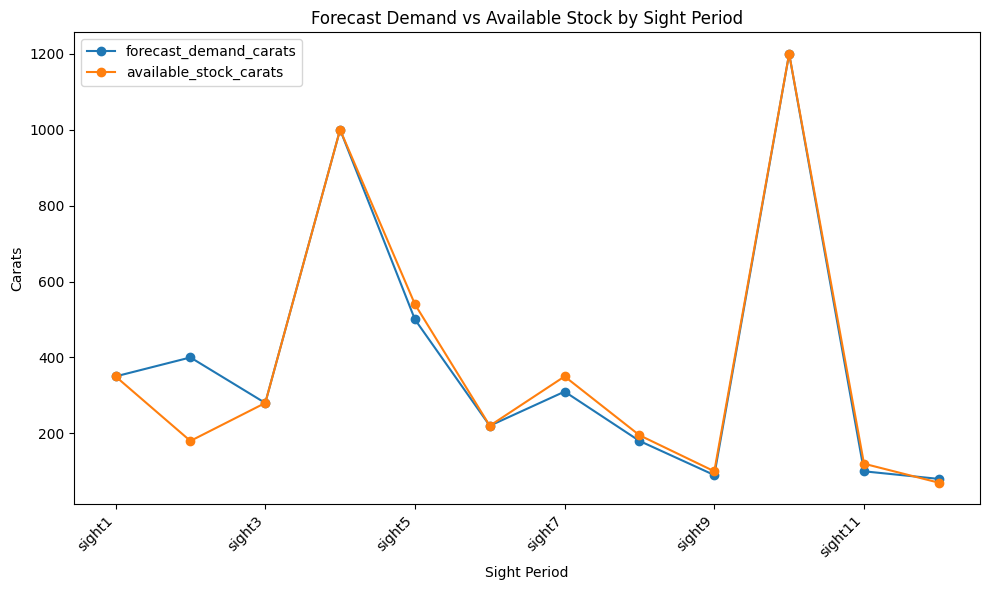

In [5]:
ax = data.plot(
    x='sight_period',
    y=['forecast_demand_carats', 'available_stock_carats'],
    kind='line',
    marker='o',
    figsize=(10,6)
)

ax.set_title('Forecast Demand vs Available Stock by Sight Period')
ax.set_xlabel('Sight Period')
ax.set_ylabel('Carats')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

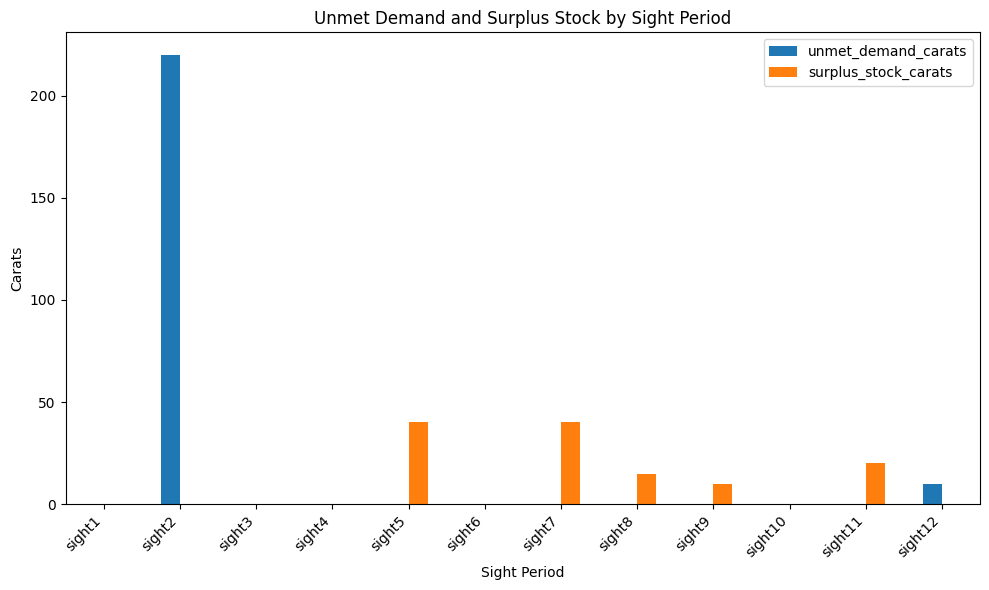

In [6]:
ax = data.plot(
    x='sight_period',
    y=['unmet_demand_carats', 'surplus_stock_carats'],
    kind='bar',
    figsize=(10,6)
)

ax.set_title('Unmet Demand and Surplus Stock by Sight Period')
ax.set_xlabel('Sight Period')
ax.set_ylabel('Carats')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Key Findings**

The analysis compared forecast demand against available stock across 12 sight periods to assess stock sufficiency and fulfilment performance. The results show that stock availability was generally aligned with demand in most periods, with full fulfilment achieved in several sight periods. However, some planning gaps were identified.

The most significant shortfall occurred in Sight 2, where forecast demand exceeded available stock by 220 carats, resulting in the lowest fulfilment rate in the dataset. A smaller shortfall was also observed in Sight 12, with 10 carats of unmet demand. These periods indicate where stock availability would need closer attention to avoid under-fulfilment.

The analysis also identified periods with surplus stock, particularly Sight 5 and Sight 7, which each recorded 40 carats above forecast demand. Additional surpluses were observed in Sight 8, Sight 9 and Sight 11. This suggests that while total stock may be adequate overall, stock imbalances can still occur across periods.

Overall, the results highlight the value of monitoring demand forecasts against stock levels at sight level in order to identify shortages early, improve fulfilment rates, and support stock balancing decisions.


**Recommendations**

1. Investigate repeated stock shortfalls

Sight periods with unmet demand, especially Sight 2, should be reviewed to determine whether the issue came from:

under-forecasting stock requirements,
poor stock allocation,
or changes in expected demand.
2. Use shortage and surplus reporting as a regular planning control

Tracking unmet demand and surplus stock by sight period provides a simple way to identify where operational adjustments are needed before the sales cycle closes.

3. Improve stock balancing across periods

Where some periods show surplus stock while others show shortages, planners should assess whether stock can be reallocated earlier to improve overall fulfilment.

4. Extend the model with actual demand and product categories

This project can be made more realistic by adding:

actual demand
diamond categories
forecast accuracy metrics
and category-level fulfilment analysis

This would allow the model to better reflect a real sales planning environment where different product groups may experience different demand and stock patterns.